# Exploratory Data Analysis of E-Commerce Sales Data

# 📋 Columns at a Glance

| Column | Description | Data Type |
|--------|-------------|------|
| `Order Date` | Date of transaction | object (datetime after conversion) |
| `Product Name` | Name of product sold | object |
| `Category` | Product category (Accessories, Electronics, Office) | object |
| `Region` | Geographic region (North, East, South, West) | object |
| `Quantity` | Number of units sold | int64 |
| `Sales` | Total sales amount | int64 |
| `Profit` | Profit generated from sale | int64 |

---

# Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data Loading and Initial Exploration



In [4]:
df = pd.read_csv('/content/ecommerce_sales_data.csv')

In [5]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


# Exploratory Data Analysis

In [6]:
df.shape

(3500, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


# Data Quality Check



In [8]:
df.isnull().sum()

,0
Order Date,0
Product Name,0
Category,0
Region,0
Quantity,0
Sales,0
Profit,0


In [9]:
df.duplicated().sum()

np.int64(0)

# Statistical Summary



In [10]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


# Unique Value Analysis



In [11]:
cols = ['Product Name','Category','Region']
print("="*60)
print("Unique values in each column")
print("="*60)
for col in cols:
  print(f"{col} : {df[col].unique()}")
  print("*"*60)

Unique values in each column
Product Name : ['Printer' 'Mouse' 'Tablet' 'Camera' 'Headphones' 'Smartwatch' 'Monitor'
 'Smartphone' 'Keyboard' 'Laptop']
************************************************************
Category : ['Office' 'Accessories' 'Electronics']
************************************************************
Region : ['North' 'East' 'South' 'West']
************************************************************


# Regional Profit Analysis



In [12]:
region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
region

,Profit
Region,
West,495358.73
East,464888.46
South,458103.27
North,426314.75


# Category-wise Profit Analysis by Region

In [13]:
table = pd.pivot_table(df,index='Region',columns='Category',values='Profit',aggfunc='sum')
table

Category,Accessories,Electronics,Office
Region,,,
East,177839.91,239660.41,47388.14
North,172153.41,221585.99,32575.35
South,187123.37,214733.11,56246.79
West,198968.05,247206.08,49184.60


# Product-wise Quantity Analysis by Region



In [14]:
table2 = pd.pivot_table(df,index='Region',columns='Product Name',values='Quantity',aggfunc='sum')
table2

Product Name,Camera,Headphones,Keyboard,Laptop,Monitor,Mouse,Printer,Smartphone,Smartwatch,Tablet
Region,,,,,,,,,,
East,410,386,469,452,424,393,379,469,517,407
North,415,386,427,414,504,387,376,346,444,407
South,527,472,427,384,448,475,500,327,390,411
West,443,360,361,408,500,498,479,475,456,508


# Category-wise Quantity Analysis by Region

In [15]:
table3 = pd.pivot_table(df,index='Region',columns='Category',values='Quantity',aggfunc='sum')
table3

Category,Accessories,Electronics,Office
Region,,,
East,1672,2255,379
North,1704,2026,376
South,1822,2039,500
West,1719,2290,479


# Time-based Analysis (Monthly and Yearly)



In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [17]:
month = df.groupby('Month')['Profit'].sum().sort_values(ascending=False)
month

,Profit
Month,
1,177280.29
12,173842.13
5,173293.15
3,162136.63
10,153027.97
8,152959.89
9,150265.04
7,149244.11
4,145620.96


# Product Category Analysis



In [18]:
product_category = df.groupby(['Product Name','Category'])['Quantity'].sum().sort_values(ascending=False)
product_category

,,Quantity
Product Name,Category,
Monitor,Accessories,1876
Smartwatch,Electronics,1807
Camera,Electronics,1795
Mouse,Accessories,1753
Printer,Office,1734
Tablet,Electronics,1733
Keyboard,Accessories,1684
Laptop,Electronics,1658
Smartphone,Electronics,1617


In [19]:
p = df.groupby('Category')['Product Name'].describe()
p

,count,unique,top,freq
Category,,,,
Accessories,1401,4,Monitor,364
Electronics,1742,5,Camera,363
Office,357,1,Printer,357


# Key Findings
1. **Data Overview**<br>
- Total Records: 3,500 transactions
- Time Period: 2022-2024
- No missing values or duplicate records found

2. **Statistical Highlights**<br>
- Average Quantity per Order: ~5 units
- Average Sales per Transaction: ₹3,048
- Average Profit per Transaction: ₹527
- Profit Range: ₹6.97 to ₹2,946.93
- Sales Range: ₹51 to ₹10,782

3. **Regional Performance**<br>
- West region leads in total profit with ₹495,358.73
- Followed by East (₹464,888.46), South (₹458,103.27), and North (₹426,314.75)
- West dominates in Electronics and Accessories profits
- South shows strong performance in Office category

4. **Category Insights**<br>
- Electronics is the largest category (1,742 transactions)
- Accessories follows with 1,401 transactions
- Office products have the fewest transactions (357)
- Monitor is the most sold product in Accessories (364 units)
- Camera leads in Electronics (363 units)
- Printer is the only Office product

5. **Product Performance**<br>
- Monitor (Accessories): Highest quantity sold (1,876 units)
- Smartwatch (Electronics): Second highest (1,807 units)
- Camera (Electronics): Third highest (1,795 units)
- Mouse (Accessories): 1,753 units
- Printer (Office): 1,734 units

6. **Temporal Patterns**<br>
- January generates the highest profit (₹177,280.29)
- February shows the lowest profit (₹118,958.72)
- Strong performance in December (₹173,842.13) and May (₹173,293.15)
- Q1 (Jan-Mar) shows strong overall performance except February dip

7. **Regional Product Preferences**<br>
- **East:** Strong in Smartwatch (517 units) and Smartphone (469 units)
- **North:** Leads in Monitor sales (504 units)
- **South:** Highest in Camera (527 units) and Printer (500 units)
- **West:** Dominates in Tablet (508 units) and Mouse (498 units)

8. **Correlation Insights**<br>
- Positive correlation between Sales and Profit (as expected)
- Quantity shows moderate correlation with both Sales and Profit
- No significant negative correlations observed

9. **Data Distribution**<br>
- Profit distribution is right-skewed with some high-value outliers
- Quantity shows fairly uniform distribution from 1-9 units
- Regional distribution is relatively balanced
- Category distribution shows Electronics dominating (~50%), followed by Accessories (~40%), and Office (~10%)

10. **Outlier Observations**<br>
- Presence of high-profit transactions (>₹2,500)
- Some transactions with very low profit margins
- Sales values show wide variation with several high-value outliers


# Data Visualization

In [20]:

# Set theme
sns.set_theme(style="whitegrid")

# Background colors
plt.rcParams['figure.facecolor'] = "#f8fafc"
plt.rcParams['axes.facecolor']   = "#ffffff"
plt.rcParams['axes.edgecolor']   = "#d1d5db"
plt.rcParams['grid.color']       = "#e2e8f0"

# Text colors
plt.rcParams['text.color'] = "#1e293b"
plt.rcParams['axes.labelcolor'] = "#334155"
plt.rcParams['xtick.color'] = "#334155"
plt.rcParams['ytick.color'] = "#334155"

# ============================================
# ATTRACTIVE THEME SETUP
# ============================================
sns.set_theme(style="whitegrid")

# Background colors
plt.rcParams['figure.facecolor'] = "#f8fafc"
plt.rcParams['axes.facecolor']   = "#ffffff"
plt.rcParams['axes.edgecolor']   = "#d1d5db"
plt.rcParams['grid.color']       = "#e2e8f0"

# Text colors
DARK_TEXT   = "#1e293b"
MID_TEXT    = "#334155"
LIGHT_TEXT  = "#64748b"

# Main color palette
PRIMARY     = "#2563eb"      # Blue - Electronics
SUCCESS     = "#16a34a"      # Green - High profit
WARNING     = "#ea580c"      # Orange - Medium profit
PURPLE      = "#9333ea"      # Purple - Accessories
TEAL        = "#0d9488"      # Teal - Office
RED         = "#dc2626"      # Red - Low profit/attention

# Region colors
REGION_COLORS = [PRIMARY, SUCCESS, WARNING, PURPLE]  # North, East, South, West

# Category colors
CATEGORY_COLORS = [PRIMARY, PURPLE, TEAL]  # Electronics, Accessories, Office

print("✅ Theme configured successfully!")

✅ Theme configured successfully!


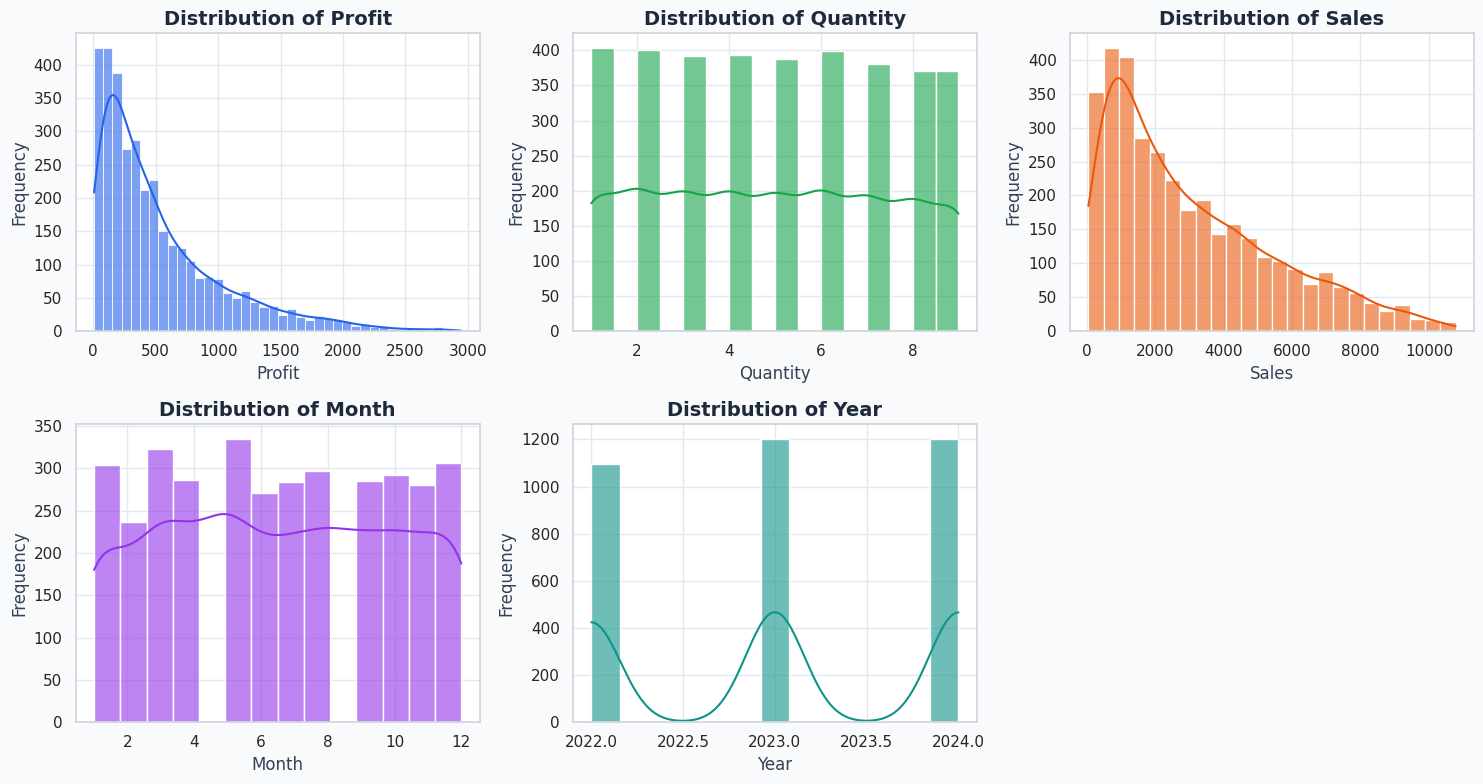

In [21]:

num_cols = ['Profit','Quantity','Sales','Month','Year']
plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)

    if col == 'Profit':
        color = PRIMARY
    elif col == 'Quantity':
        color = SUCCESS
    elif col == 'Sales':
        color = WARNING
    elif col == 'Month':
        color = PURPLE
    else:
        color = TEAL

    sns.histplot(df[col], kde=True, color=color, alpha=0.6, edgecolor='white')
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold', color=DARK_TEXT)
    plt.xlabel(col, color=MID_TEXT)
    plt.ylabel('Frequency', color=MID_TEXT)


plt.subplot(2, 3, 6).set_visible(False)

plt.tight_layout()
plt.show()

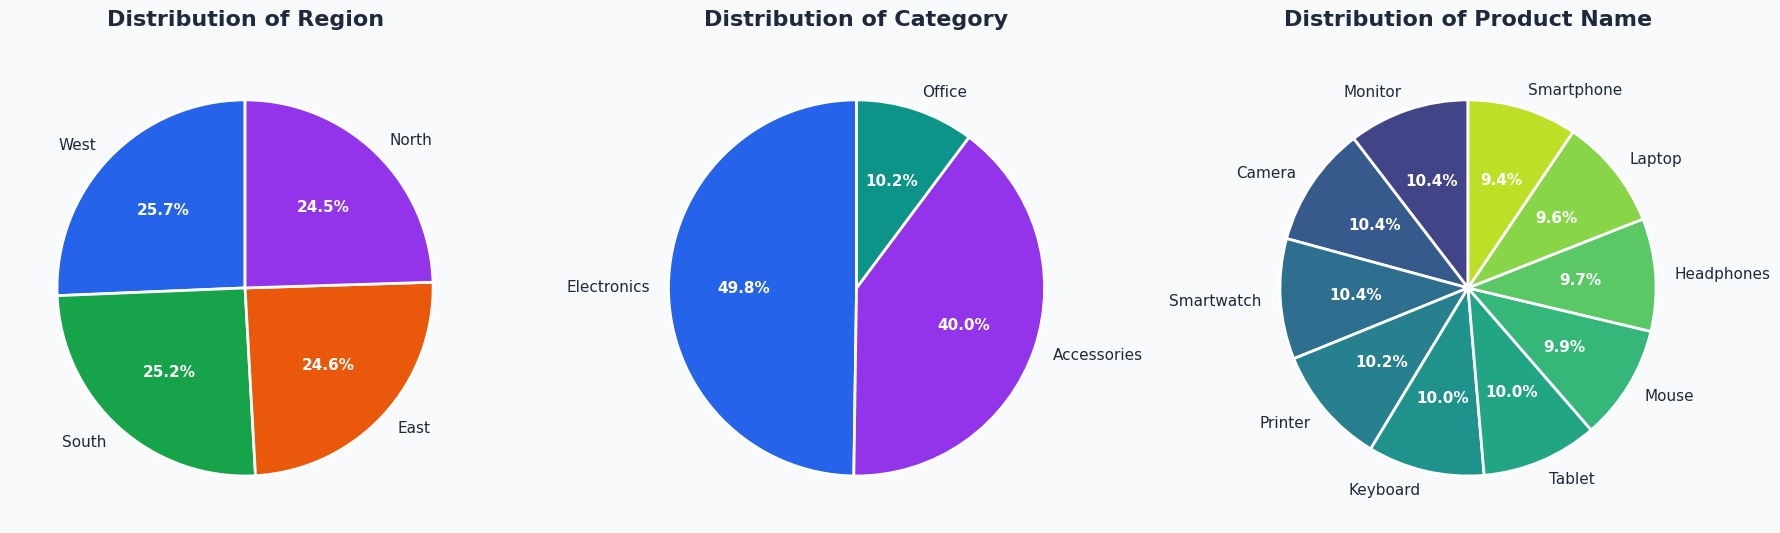

In [22]:
cat_cols = ['Region', 'Category', 'Product Name']
plt.figure(figsize=(18, 6))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)

    values = df[col].value_counts().values
    labels = df[col].value_counts().index

    # Assign colors based on column
    if col == 'Region':
        colors = [PRIMARY, SUCCESS, WARNING, PURPLE]  # North, East, South, West
    elif col == 'Category':
        colors = [PRIMARY, PURPLE, TEAL]  # Electronics, Accessories, Office
    else:
        colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(labels)))

    wedges, texts, autotexts = plt.pie(values,
                                        labels=labels,
                                        autopct='%1.1f%%',
                                        colors=colors,
                                        startangle=90,
                                        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
                                        textprops={'fontsize': 11})

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(11)

    for text in texts:
        text.set_fontsize(11)
        text.set_color(DARK_TEXT)

    plt.title(f'Distribution of {col}', fontsize=16, fontweight='bold', color=DARK_TEXT, pad=20)

plt.tight_layout()
plt.show()

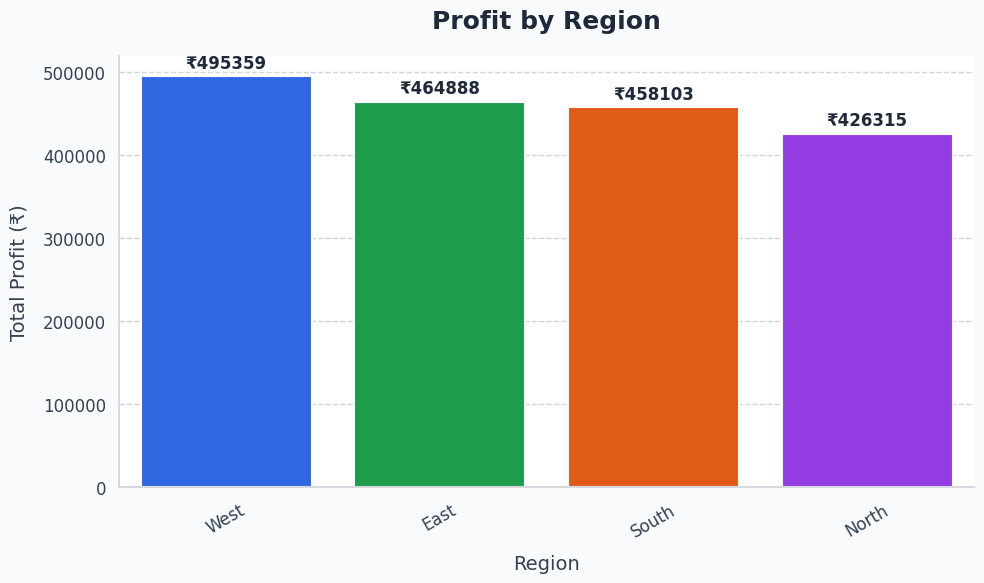

In [23]:
plt.figure(figsize=(10, 6))


ax = sns.barplot(x=region.index,
                 y=region.values,
                 palette=REGION_COLORS,
                 edgecolor='white',
                 linewidth=1.5,
                 saturation=0.9)


for container in ax.containers:
    ax.bar_label(container,
                 fmt='₹%.0f',  # Format as currency
                 fontsize=12,
                 fontweight='bold',
                 color=DARK_TEXT,
                 padding=3)


plt.title('Profit by Region', fontsize=18, fontweight='bold', color=DARK_TEXT, pad=20)
plt.xlabel('Region', fontsize=14, color=MID_TEXT, labelpad=10)
plt.ylabel('Total Profit (₹)', fontsize=14, color=MID_TEXT, labelpad=10)
plt.xticks(rotation=30, fontsize=12, color=MID_TEXT)
plt.yticks(fontsize=12, color=MID_TEXT)
plt.grid(axis='y', alpha=0.3, linestyle='--', color=LIGHT_TEXT)
sns.despine()
plt.tight_layout()
plt.show()

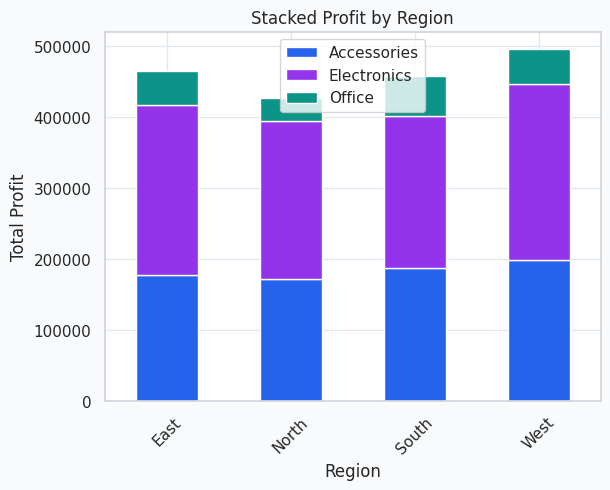

In [24]:
CATEGORY_COLORS = ['#2563eb', '#9333ea', '#0d9488']  # Electronics, Accessories, Office


table.plot(kind='bar', stacked=True, color=CATEGORY_COLORS,
           edgecolor='white',
           linewidth=1,)
plt.title("Stacked Profit by Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.legend(loc='upper center')
plt.show()

<Figure size 1500x600 with 0 Axes>

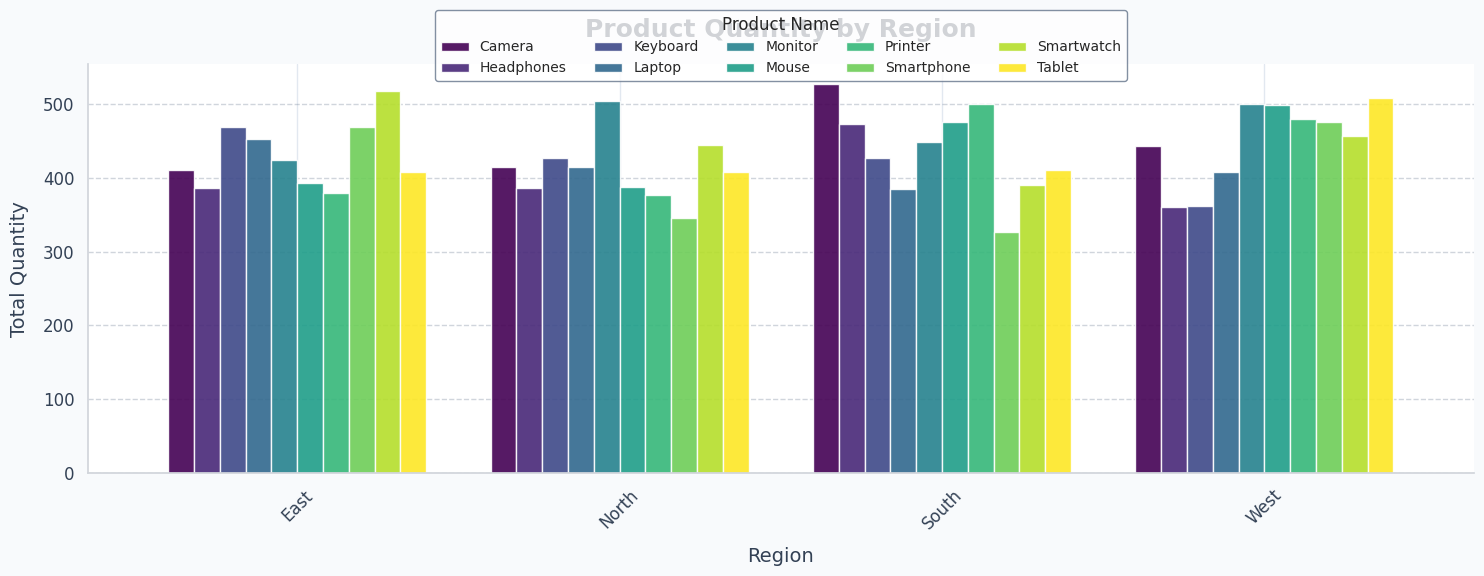

In [25]:
plt.figure(figsize=(15, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(table2.columns)))

ax = table2.plot(kind='bar',
                 figsize=(15, 6),
                 color=colors,
                 edgecolor='white',
                 linewidth=1,
                 width=0.8,
                 alpha=0.9)

plt.title('Product Quantity by Region', fontsize=18, fontweight='bold', color=DARK_TEXT, pad=20)
plt.ylabel('Total Quantity', fontsize=14, color=MID_TEXT, labelpad=10)
plt.xlabel('Region', fontsize=14, color=MID_TEXT, labelpad=10)

plt.xticks(rotation=45, fontsize=12, color=MID_TEXT)
plt.yticks(fontsize=12, color=MID_TEXT)
plt.legend(loc='upper center',
          bbox_to_anchor=(0.5, 1.15),
          ncol=5,
          title='Product Name',
          title_fontsize=12,
          fontsize=10,
          frameon=True,
          facecolor='white',
          edgecolor=LIGHT_TEXT,
          shadow=False)
plt.grid(axis='y', alpha=0.3, linestyle='--', color=LIGHT_TEXT)
sns.despine()
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

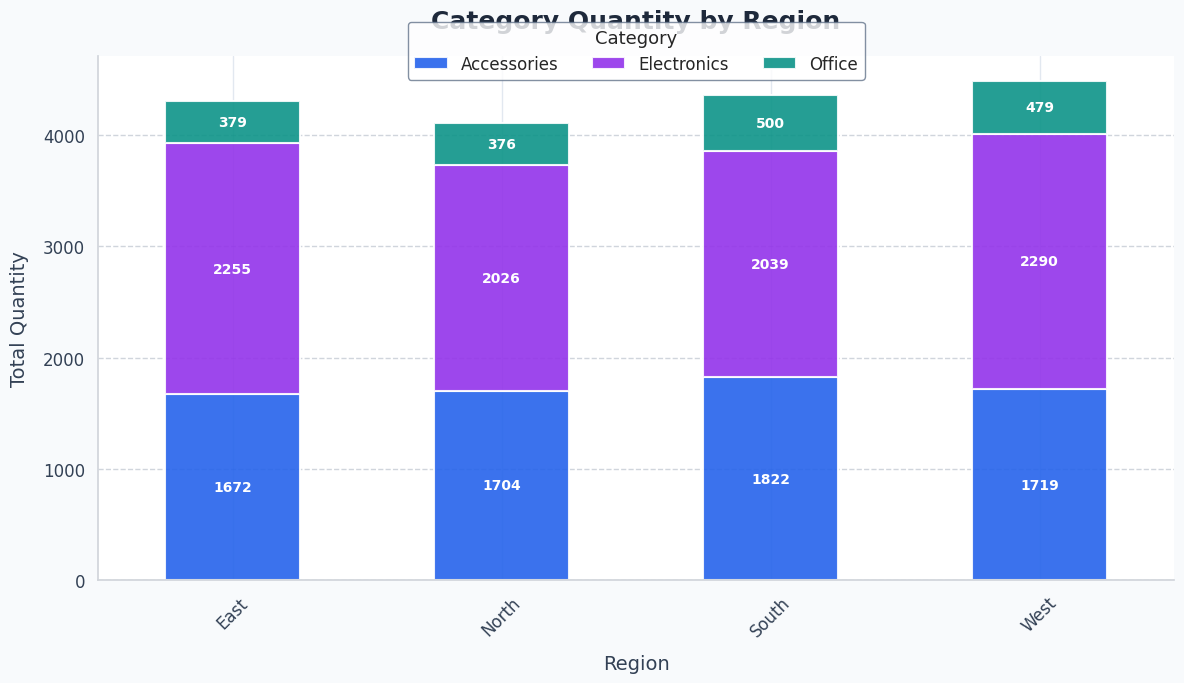

In [26]:
plt.figure(figsize=(8, 5))

ax = table3.plot(kind='bar',
                 stacked=True,
                 color=[PRIMARY, PURPLE, TEAL],  # Electronics, Accessories, Office
                 edgecolor='white',
                 linewidth=1.5,
                 figsize=(12, 7),
                 alpha=0.9)

plt.title('Category Quantity by Region', fontsize=18, fontweight='bold', color=DARK_TEXT, pad=20)
plt.ylabel('Total Quantity', fontsize=14, color=MID_TEXT, labelpad=10)
plt.xlabel('Region', fontsize=14, color=MID_TEXT, labelpad=10)

plt.xticks(rotation=45, fontsize=12, color=MID_TEXT)
plt.yticks(fontsize=12, color=MID_TEXT)

plt.legend(loc='upper center',
          bbox_to_anchor=(0.5, 1.08),
          title='Category',
          title_fontsize=13,
          fontsize=12,
          frameon=True,
          facecolor='white',
          edgecolor=LIGHT_TEXT,
          ncol=3)

plt.grid(axis='y', alpha=0.3, linestyle='--', color=LIGHT_TEXT)
sns.despine()

for container in ax.containers:
    ax.bar_label(container,
                 label_type='center',
                 fontsize=10,
                 color='white',
                 fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1400x700 with 0 Axes>

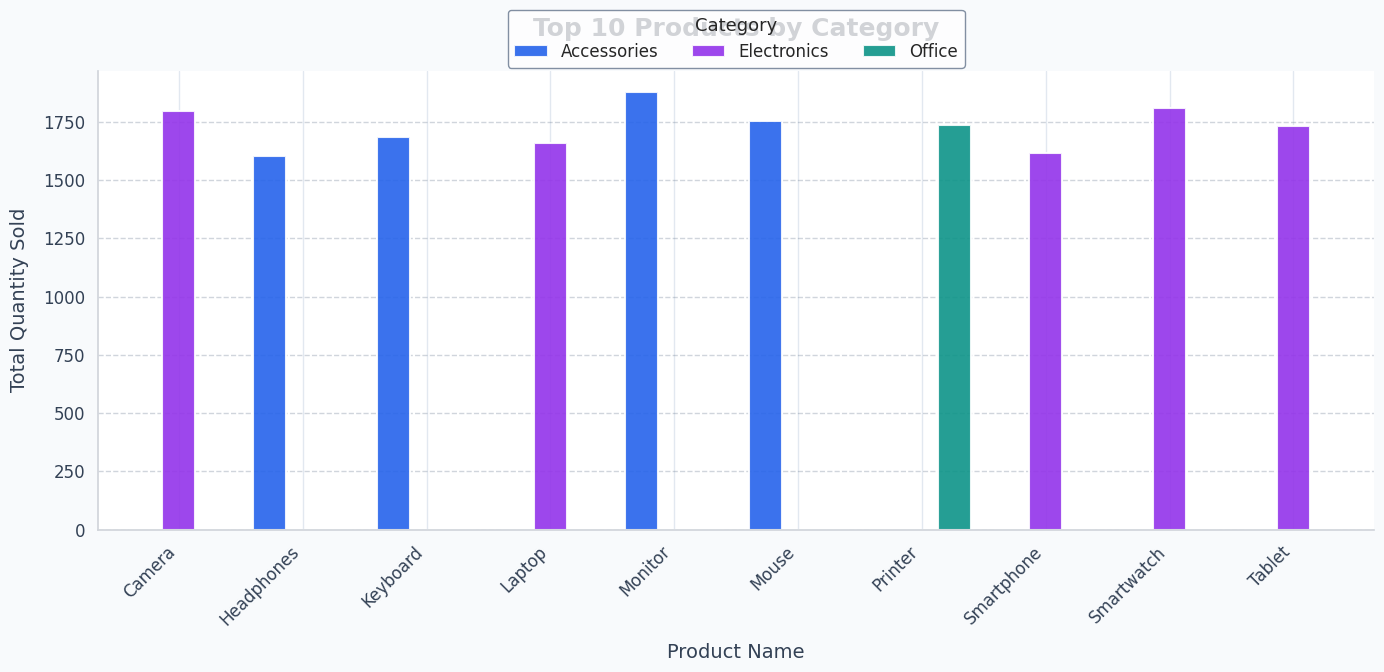

In [27]:
product_category = df.groupby(['Product Name','Category'])['Quantity'].sum().sort_values(ascending=False)
product_category_df = product_category.reset_index()
pivot_table = product_category_df.pivot(index='Product Name', columns='Category', values='Quantity')

plt.figure(figsize=(14, 7))
ax = pivot_table.head(10).plot(kind='bar',
                               figsize=(14, 7),
                               color=[PRIMARY, PURPLE, TEAL],
                               edgecolor='white',
                               linewidth=1.5,
                               width=0.8,
                               alpha=0.9)
plt.title('Top 10 Products by Category', fontsize=18, fontweight='bold', color=DARK_TEXT, pad=25)
plt.xlabel('Product Name', fontsize=14, color=MID_TEXT, labelpad=10)
plt.ylabel('Total Quantity Sold', fontsize=14, color=MID_TEXT, labelpad=10)
plt.xticks(rotation=45, fontsize=12, color=MID_TEXT, ha='right')
plt.yticks(fontsize=12, color=MID_TEXT)
plt.legend(loc='upper center',
          bbox_to_anchor=(0.5, 1.15),
          title='Category',
          title_fontsize=13,
          fontsize=12,
          frameon=True,
          facecolor='white',
          edgecolor=LIGHT_TEXT,
          ncol=3)
plt.grid(axis='y', alpha=0.3, linestyle='--', color=LIGHT_TEXT)
sns.despine()
plt.tight_layout()
plt.show()


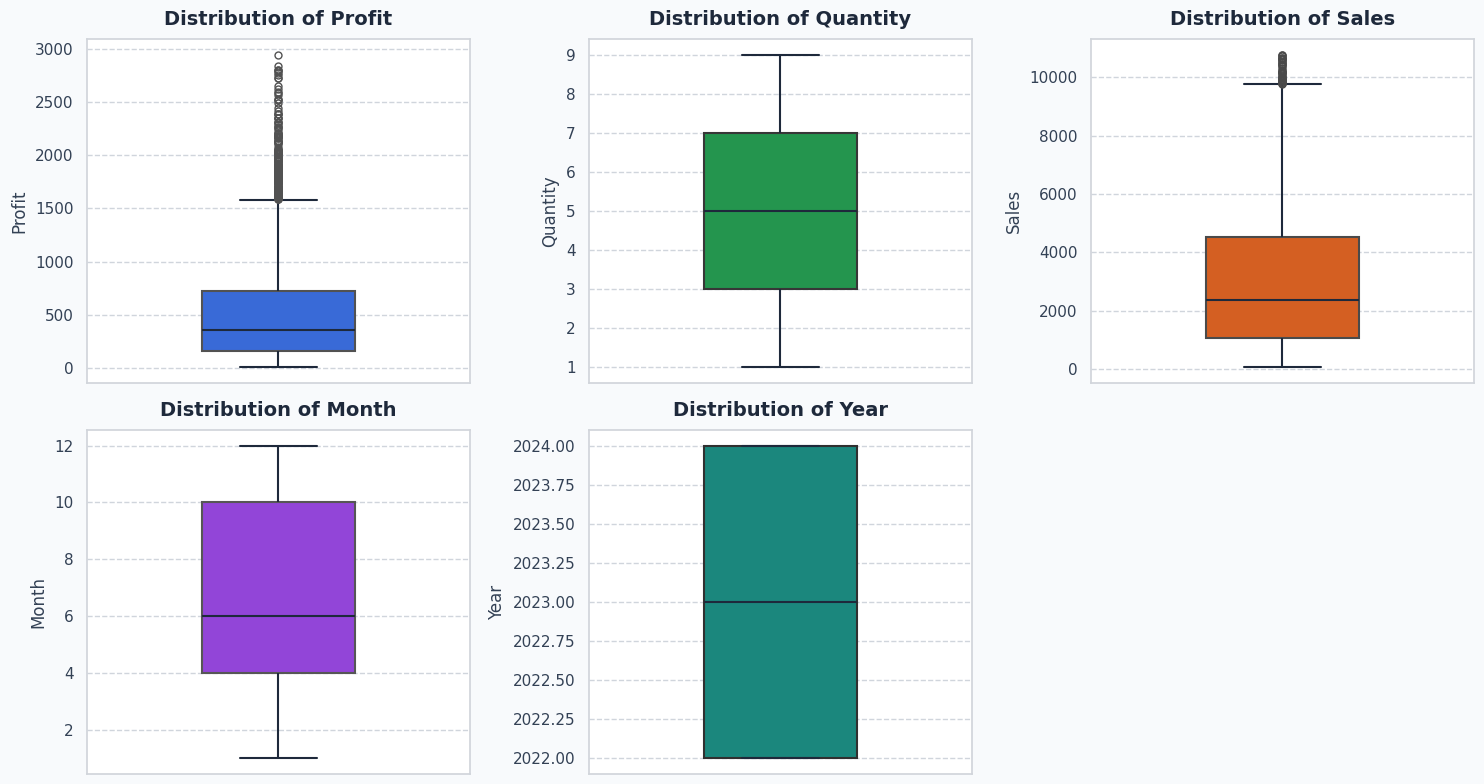

In [28]:
num_cols = ['Profit', 'Quantity', 'Sales', 'Month', 'Year']
plt.figure(figsize=(15, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    if col == 'Profit':
        color = PRIMARY
    elif col == 'Quantity':
        color = SUCCESS
    elif col == 'Sales':
        color = WARNING
    elif col == 'Month':
        color = PURPLE
    else:  # Year
        color = TEAL

    box = sns.boxplot(data=df,
                      y=col,
                      color=color,
                      width=0.4,
                      saturation=0.8,
                      linewidth=1.5,
                      fliersize=5)

    for i, artist in enumerate(box.artists):
        artist.set_edgecolor(DARK_TEXT)
        artist.set_linewidth(1.5)

    plt.setp(box.lines, color=DARK_TEXT, linewidth=1.5)
    plt.setp(box.get_xticklabels(), fontsize=11, color=MID_TEXT)
    plt.setp(box.get_yticklabels(), fontsize=11, color=MID_TEXT)

    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold', color=DARK_TEXT, pad=10)
    plt.ylabel(col, fontsize=12, color=MID_TEXT, labelpad=5)
    plt.xlabel('')

    plt.grid(axis='y', alpha=0.3, linestyle='--', color=LIGHT_TEXT)

plt.subplot(2, 3, 6).set_visible(False)
plt.tight_layout()
plt.show()

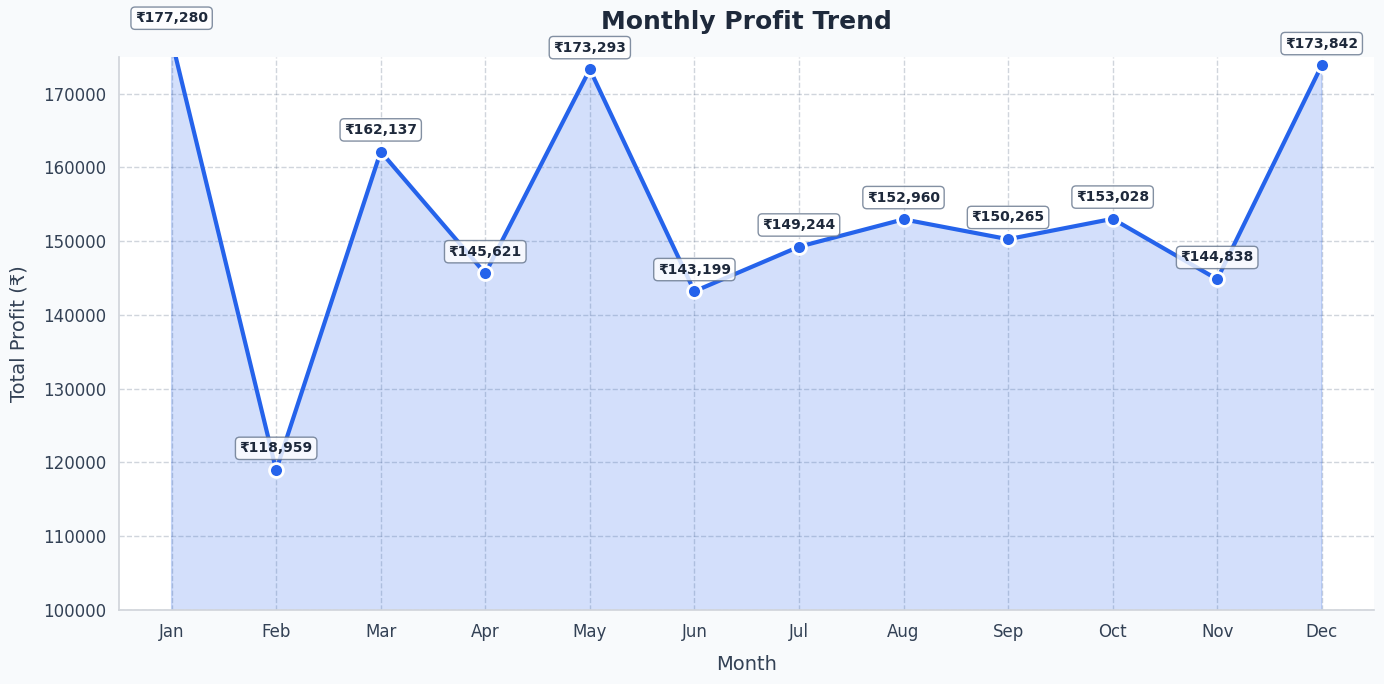

In [29]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='Month',
             y='Profit',
             data=df,
             color=PRIMARY,
             linewidth=3,
             marker='o',
             markersize=10,
             markeredgecolor='white',
             markeredgewidth=2,
             markerfacecolor=PRIMARY,
             ci=None,
             estimator=sum)

monthly_data = df.groupby('Month')['Profit'].sum().reset_index()
plt.fill_between(monthly_data['Month'],
                 monthly_data['Profit'],
                 alpha=0.2,
                 color=PRIMARY)
plt.xlim(0.5, 12.5)
plt.ylim(100000,175000)
plt.xticks(range(1, 13),
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
           fontsize=12,
           color=MID_TEXT)

plt.title('Monthly Profit Trend', fontsize=18, fontweight='bold', color=DARK_TEXT, pad=20)
plt.xlabel('Month', fontsize=14, color=MID_TEXT, labelpad=10)
plt.ylabel('Total Profit (₹)', fontsize=14, color=MID_TEXT, labelpad=10)
plt.yticks(fontsize=12, color=MID_TEXT)
plt.grid(True, alpha=0.3, linestyle='--', color=LIGHT_TEXT)
for x, y in zip(monthly_data['Month'], monthly_data['Profit']):
    plt.text(x, y + 2000, f'₹{y:,.0f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold',
             color=DARK_TEXT,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=LIGHT_TEXT))

sns.despine()
plt.tight_layout()
plt.show()

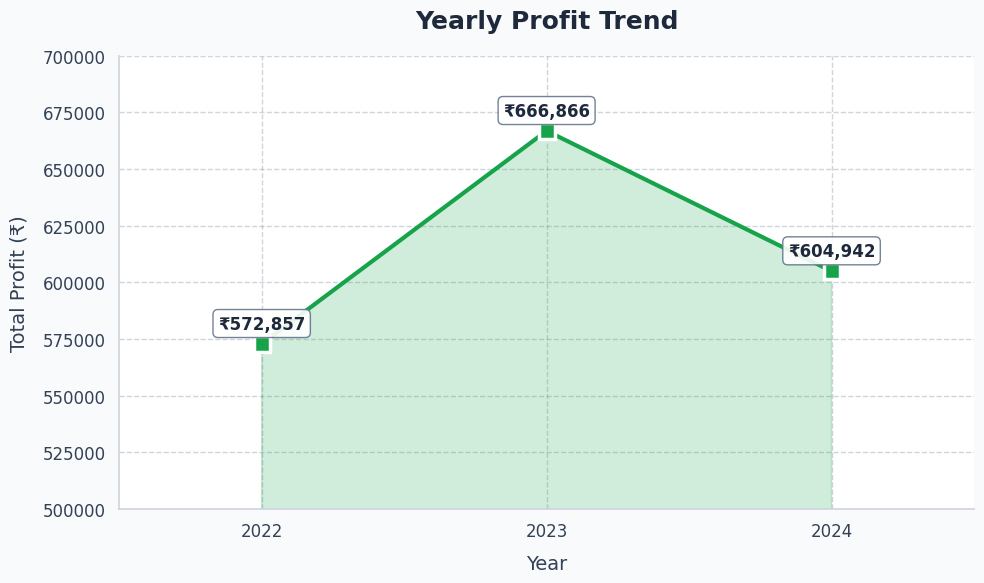

In [30]:
plt.figure(figsize=(10, 6))
yearly_profit = df.groupby('Year')['Profit'].sum().reset_index()

sns.lineplot(x='Year',
             y='Profit',
             data=yearly_profit,
             color=SUCCESS,
             linewidth=3,
             marker='s',
             markersize=12,
             markeredgecolor='white',
             markeredgewidth=2.5,
             markerfacecolor=SUCCESS)

plt.fill_between(yearly_profit['Year'],
                 yearly_profit['Profit'],
                 alpha=0.2,
                 color=SUCCESS)

plt.xlim(2021.5, 2024.5)
plt.xticks([2022, 2023, 2024], fontsize=12, color=MID_TEXT)
plt.ylim(500000,700000)
plt.title('Yearly Profit Trend', fontsize=18, fontweight='bold', color=DARK_TEXT, pad=20)
plt.xlabel('Year', fontsize=14, color=MID_TEXT, labelpad=10)
plt.ylabel('Total Profit (₹)', fontsize=14, color=MID_TEXT, labelpad=10)
plt.yticks(fontsize=12, color=MID_TEXT)
plt.grid(True, alpha=0.3, linestyle='--', color=LIGHT_TEXT)

for x, y in zip(yearly_profit['Year'], yearly_profit['Profit']):
    plt.text(x, y + 5000, f'₹{y:,.0f}',
             ha='center', va='bottom',
             fontsize=12, fontweight='bold',
             color=DARK_TEXT,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor=LIGHT_TEXT))

sns.despine()
plt.tight_layout()
plt.show()

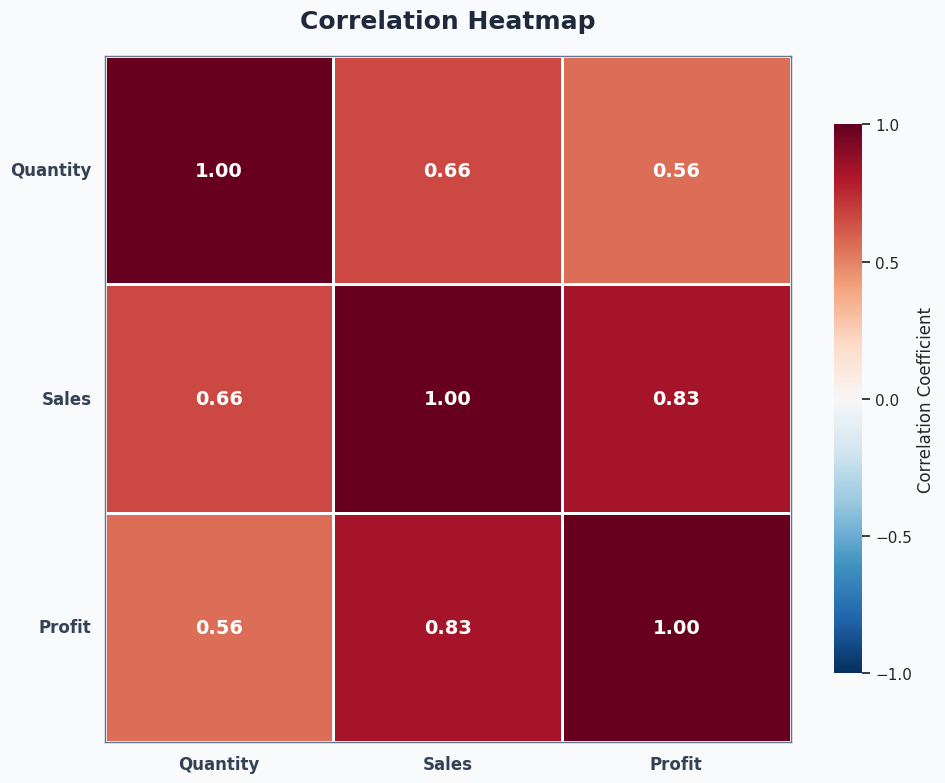

In [31]:
plt.figure(figsize=(10, 8))
corr_matrix = df[['Quantity', 'Sales', 'Profit']].corr()
sns.heatmap(corr_matrix,
            annot=True,
            annot_kws={"size": 14, "fontweight": "bold", "color": "white"},
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=2,
            linecolor='white',
            cbar=True,
            cbar_kws={
                "shrink": 0.8,
                "label": "Correlation Coefficient",
                "ticks": [-1, -0.5, 0, 0.5, 1],
                "orientation": "vertical",
                "pad": 0.05
            },
            fmt='.2f',
            mask=None,
            xticklabels=True,
            yticklabels=True)

plt.title('Correlation Heatmap', fontsize=18, fontweight='bold', color=DARK_TEXT, pad=20)
plt.xticks(fontsize=12, fontweight='semibold', color=MID_TEXT, rotation=0)
plt.yticks(fontsize=12, fontweight='semibold', color=MID_TEXT, rotation=0)
for _, spine in plt.gca().spines.items():
    spine.set_visible(True)
    spine.set_color(LIGHT_TEXT)
    spine.set_linewidth(1)

plt.tight_layout()
plt.show()